## Practical intuition for avoiding biased conclusions in observational and experimental data
## Abstract

This tutorial builds practical intuition for causal graphs and how they help us reason about bias in observational data. Using original examples from marketing and product analytics, it shows how confounding, colliders, and selection bias can create misleading conclusions even before any model is fit.

The goal is not just to explain DAGs mechanically, but to show how they help answer a practical question: **what should we control for, and what should we avoid controlling for, if we want a causal interpretation?**

---

## Introduction

This tutorial builds on standard causal inference concepts and uses **original examples, variables, and business scenarios** so that each concept stands on its own.

The focus is on **practical intuition** — understanding how confounding, colliders, and selection bias arise in real-world data, and how causal graphs help avoid incorrect conclusions.

In practice, many analytical mistakes come not from the model, but from **conditioning on the wrong variables**.

We will cover:

1. **Three basic graphical patterns** — chain, fork, and collider  
2. A more complex **product analytics DAG** and d-separation using a custom helper on `networkx`  
3. **Backdoor paths and confounding** with a marketing email and revenue example  
4. The **adjustment formula** with a small toy dataset  
5. **Selection bias** in a feature-rating survey, showing how even A/B-style analyses can lie  

We avoid `pgmpy` completely and implement a lightweight `is_d_separated` helper using `networkx`, so the tutorial stays simple and robust to library issues.

---

## Why This Matters

In real-world analytics, it is easy to confuse:

- correlation with causation  
- a useful predictor with a valid control variable  
- a filtered sample with an unbiased sample  

Causal graphs help prevent these mistakes by making assumptions explicit.

A good DAG does not guarantee a correct answer, but it makes it much easier to see:

- where bias comes from  
- which paths should be blocked  
- which variables should **not** be adjusted for  

---

## Core Question

The central question in this tutorial is:

> When does conditioning remove bias, and when does it create bias?

That question sits underneath a lot of practical business problems, such as:

- Does sending a marketing email increase revenue?  
- Does a product intervention improve engagement?  
- Should we control for a variable because it is predictive, or leave it out because it is post-treatment or a collider?  

---

## Reference

Facure, Matheus. *Causal Inference for the Brave and True*  
https://matheusfacure.github.io/python-causality-handbook/

---


## 1. Setup and d-separation helper


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

np.random.seed(42)
pd.set_option("display.precision", 4)

def _ancestors(G, nodes):
    """Return all ancestors of a set of nodes in a directed graph G."""
    anc = set()
    stack = list(nodes)
    while stack:
        n = stack.pop()
        for p in G.predecessors(n):
            if p not in anc:
                anc.add(p)
                stack.append(p)
    return anc

def is_d_separated(G, X, Y, Z):
    """
    Check d-separation between sets X and Y given Z in DAG G using
    the moralized ancestral graph method.

    G : networkx.DiGraph
    X, Y, Z : iterables of node labels

    Returns True if X and Y are d-separated given Z, False otherwise.
    """
    X = set(X); Y = set(Y); Z = set(Z)

    # 1. Keep only ancestors of X ∪ Y ∪ Z (plus themselves)
    relevant = set(X) | set(Y) | set(Z)
    relevant |= _ancestors(G, relevant)
    H = G.subgraph(relevant).copy()

    # 2. Moralize: undirected graph, connect parents of each child
    M = nx.Graph()
    M.add_nodes_from(H.nodes())
    # undirected versions of all edges
    for u, v in H.edges():
        M.add_edge(u, v)
    # marry parents
    for child in H.nodes():
        parents = list(H.predecessors(child))
        for i in range(len(parents)):
            for j in range(i + 1, len(parents)):
                M.add_edge(parents[i], parents[j])

    # 3. Remove observed nodes Z
    M.remove_nodes_from(Z)

    # 4. Check if any node in X is connected to any node in Y
    for x in X:
        if x not in M:
            continue
        comp = nx.node_connected_component(M, x)
        if any(y in comp for y in Y):
            return False  # not d-separated (path exists)
    return True  # d-separated

# Quick sanity check on the three basic patterns
if __name__ == "__main__":
    G_chain = nx.DiGraph([("X","M"),("M","Y")])
    print("Chain X,Y | ∅:", is_d_separated(G_chain, {"X"},{"Y"}, set()))       # False
    print("Chain X,Y | M:", is_d_separated(G_chain, {"X"},{"Y"},{"M"}))       # True

    G_fork = nx.DiGraph([("C","X"),("C","Y")])
    print("Fork X,Y | ∅:", is_d_separated(G_fork, {"X"},{"Y"}, set()))        # False
    print("Fork X,Y | C:", is_d_separated(G_fork, {"X"},{"Y"},{"C"}))         # True

    G_col = nx.DiGraph([("X","C"),("Y","C")])
    print("Coll X,Y | ∅:", is_d_separated(G_col, {"X"},{"Y"}, set()))         # True
    print("Coll X,Y | C:", is_d_separated(G_col, {"X"},{"Y"},{"C"}))          # False


Chain X,Y | ∅: False
Chain X,Y | M: True
Fork X,Y | ∅: False
Fork X,Y | C: True
Coll X,Y | ∅: True
Coll X,Y | C: False


## 2. Three Fundamental Causal Structures

We look at:

1. **Chain**: X → M → Y  
2. **Fork (common cause)**: X ← C → Y  
3. **Collider (common effect)**: X → C ← Y  

We will use a `networkx.DiGraph` and our `is_d_separated` helper to see when variables are  
independent or dependent, with and without conditioning.


### 2.1 Chain: `X → M → Y`


In [2]:
# Chain: X → M → Y
chain = nx.DiGraph([
    ("X", "M"),
    ("M", "Y"),
])

print("Are X and Y d-separated with NO conditioning?")
print(is_d_separated(chain, {"X"}, {"Y"}, set()))  # Expect False (they are connected through M)

print("\nAre X and Y d-separated GIVEN M? (conditioning on mediator)")
print(is_d_separated(chain, {"X"}, {"Y"}, {"M"}))  # Expect True (conditioning blocks the chain)

print("\nAre X and Y dependent (no conditioning)?", not is_d_separated(chain, {"X"}, {"Y"}, set()))
print("Are X and Y dependent given M?", not is_d_separated(chain, {"X"}, {"Y"}, {"M"}))

Are X and Y d-separated with NO conditioning?
False

Are X and Y d-separated GIVEN M? (conditioning on mediator)
True

Are X and Y dependent (no conditioning)? True
Are X and Y dependent given M? False


**Intuition**

- No conditioning → X and Y are associated via the path X → M → Y.  
- Conditioning on M → you block the path and X and Y become independent in the graph (d-separated).

### 2.2 Fork: `X ← C → Y` (Common Cause / Confounder)


In [3]:
# Fork: C is a common cause of X and Y
fork = nx.DiGraph([
    ("C", "X"),
    ("C", "Y"),
])

print("Are X and Y d-separated with NO conditioning?")
print(is_d_separated(fork, {"X"}, {"Y"}, set()))  # Expect False: they share C

print("\nAre X and Y d-separated GIVEN C?")
print(is_d_separated(fork, {"X"}, {"Y"}, {"C"}))  # Expect True: conditioning on C blocks path

print("\nAre X and Y dependent (no conditioning)?", not is_d_separated(fork, {"X"}, {"Y"}, set()))
print("Are X and Y dependent given C?", not is_d_separated(fork, {"X"}, {"Y"}, {"C"}))

Are X and Y d-separated with NO conditioning?
False

Are X and Y d-separated GIVEN C?
True

Are X and Y dependent (no conditioning)? True
Are X and Y dependent given C? False


Here C acts as a **confounder**:

- Without conditioning, X and Y move together because they both depend on C.  
- When you condition on C, you remove that shared variation and X and Y become independent.  
- This pattern shows why you need to adjust for confounders in causal inference.


### 2.3 Collider: `X → C ← Y` (Common Effect / Selection)


In [4]:
# Collider: C is a common effect of X and Y
collider = nx.DiGraph([
    ("X", "C"),
    ("Y", "C"),
])

print("Are X and Y d-separated with NO conditioning?")
print(is_d_separated(collider, {"X"}, {"Y"}, set()))  # Expect True: collider blocks path

print("\nAre X and Y d-separated GIVEN C?")
print(is_d_separated(collider, {"X"}, {"Y"}, {"C"}))  # Expect False: conditioning opens path

print("\nAre X and Y dependent (no conditioning)?", not is_d_separated(collider, {"X"}, {"Y"}, set()))
print("Are X and Y dependent given C?", not is_d_separated(collider, {"X"}, {"Y"}, {"C"}))

Are X and Y d-separated with NO conditioning?
True

Are X and Y d-separated GIVEN C?
False

Are X and Y dependent (no conditioning)? False
Are X and Y dependent given C? True


**Key lesson**

- Without conditioning, the path X → C ← Y is **blocked** at the collider C. X and Y are independent.  
- When you condition on C (or on a descendant of C), you **create** a spurious association between X and Y.  
- This is the structural origin of many kinds of **selection bias**.


## 3. A Product Analytics DAG: Segments, Ads, UI Experiments, and Churn

Now let's build a slightly more realistic product analytics DAG.

Nodes:

- `SEG` = user segment (e.g. high-value / low-value)  
- `H_ISS` = historic issues (number of old tickets)  
- `UI_EXP` = whether the user is assigned to a new UI experiment  
- `AD` = ad exposure level  
- `SUPPORT` = support team load  
- `FAQ` = FAQ visits  
- `CHURN` = whether the user churns


In [5]:
product_model = nx.DiGraph([
    ("SEG", "UI_EXP"),
    ("SEG", "AD"),
    ("H_ISS", "UI_EXP"),
    ("AD", "FAQ"),
    ("SUPPORT", "FAQ"),
    ("UI_EXP", "CHURN"),
])

### 3.1 Collider at `UI_EXP`: `SEG → UI_EXP ← H_ISS`


In [6]:
print("Are SEG and H_ISS d-separated with NO conditioning?")
print(is_d_separated(product_model, {"SEG"}, {"H_ISS"}, set()))  # Expect True

print("\nAre SEG and H_ISS d-separated GIVEN UI_EXP?")
print(is_d_separated(product_model, {"SEG"}, {"H_ISS"}, {"UI_EXP"}))  # Expect False

print("\nAre SEG and H_ISS dependent (no conditioning)?", 
      not is_d_separated(product_model, {"SEG"}, {"H_ISS"}, set()))
print("Are SEG and H_ISS dependent given UI_EXP?",
      not is_d_separated(product_model, {"SEG"}, {"H_ISS"}, {"UI_EXP"}))

Are SEG and H_ISS d-separated with NO conditioning?
True

Are SEG and H_ISS d-separated GIVEN UI_EXP?
False

Are SEG and H_ISS dependent (no conditioning)? False
Are SEG and H_ISS dependent given UI_EXP? True


Here `UI_EXP` is a **collider** between `SEG` and `H_ISS`.  
If you analyze only users in the experiment (conditioning on `UI_EXP=1`), you can create fake dependence between segment and historic issues.


### 3.2 Collider at `FAQ`: `AD → FAQ ← SUPPORT`


In [7]:
print("Are AD and SUPPORT d-separated with NO conditioning?")
print(is_d_separated(product_model, {"AD"}, {"SUPPORT"}, set()))  # Expect True

print("\nAre AD and SUPPORT d-separated GIVEN FAQ?")
print(is_d_separated(product_model, {"AD"}, {"SUPPORT"}, {"FAQ"}))  # Expect False

print("\nAre AD and SUPPORT dependent (no conditioning)?", 
      not is_d_separated(product_model, {"AD"}, {"SUPPORT"}, set()))
print("Are AD and SUPPORT dependent given FAQ?",
      not is_d_separated(product_model, {"AD"}, {"SUPPORT"}, {"FAQ"}))

Are AD and SUPPORT d-separated with NO conditioning?
True

Are AD and SUPPORT d-separated GIVEN FAQ?
False

Are AD and SUPPORT dependent (no conditioning)? False
Are AD and SUPPORT dependent given FAQ? True


Again, `FAQ` is a collider: users who hit FAQ a lot are more likely to have either high ad exposure or high support load (or both).  
Conditioning on FAQ visit can create spurious relationships between AD and SUPPORT.


### 3.3 Chain `H_ISS → UI_EXP → CHURN`


In [8]:
print("Are H_ISS and CHURN d-separated with NO conditioning?")
print(is_d_separated(product_model, {"H_ISS"}, {"CHURN"}, set()))  # Expect False

print("\nAre H_ISS and CHURN d-separated GIVEN UI_EXP?")
print(is_d_separated(product_model, {"H_ISS"}, {"CHURN"}, {"UI_EXP"}))  # Expect True

print("\nAre H_ISS and CHURN dependent (no conditioning)?", 
      not is_d_separated(product_model, {"H_ISS"}, {"CHURN"}, set()))
print("Are H_ISS and CHURN dependent given UI_EXP?",
      not is_d_separated(product_model, {"H_ISS"}, {"CHURN"}, {"UI_EXP"}))

Are H_ISS and CHURN d-separated with NO conditioning?
False

Are H_ISS and CHURN d-separated GIVEN UI_EXP?
True

Are H_ISS and CHURN dependent (no conditioning)? True
Are H_ISS and CHURN dependent given UI_EXP? False


Here `UI_EXP` is a **mediator** on the path from `H_ISS` to `CHURN`.  
Conditioning on `UI_EXP` blocks the chain and removes the association.


## 4. Backdoor Paths and Confounding: Email Campaign & Revenue

Now we show **confounding** with a compact marketing example.

Variables:

- `revenue_prev` – previous month's revenue  
- `email_campaign` – binary flag: 1 if the customer was targeted  
- `revenue_next` – next month's revenue

Causal story:

- Higher `revenue_prev` customers are more likely to be targeted.  
- Higher `revenue_prev` also predicts higher `revenue_next`.  
- The email may give a modest lift to `revenue_next`.


In [9]:
marketing_model = nx.DiGraph([
    ("revenue_prev", "email_campaign"),
    ("revenue_prev", "revenue_next"),
    ("email_campaign", "revenue_next"),
])

# To see if there is a noncausal backdoor path from email_campaign to revenue_next,
# we conceptually remove the direct arrow email_campaign → revenue_next
marketing_severed = nx.DiGraph([
    ("revenue_prev", "email_campaign"),
    ("revenue_prev", "revenue_next"),
])

print("Are email_campaign and revenue_next d-separated in the severed graph?")
print(is_d_separated(marketing_severed, {"email_campaign"}, {"revenue_next"}, set()))

print("\nAre they still dependent (backdoor path exists)?",
      not is_d_separated(marketing_severed, {"email_campaign"}, {"revenue_next"}, set()))

Are email_campaign and revenue_next d-separated in the severed graph?
False

Are they still dependent (backdoor path exists)? True


Because of the common cause `revenue_prev`, even after we conceptually remove the direct causal arrow,  
`email_campaign` and `revenue_next` are still connected through a **backdoor path**.  
That means there is **confounding**, and naive comparisons will be biased.


## 5. Adjustment Formula with a Toy Dataset

Let’s build a tiny dataset of six customers to show how the **adjustment formula** works in practice.


In [10]:
df = pd.DataFrame({
    "revenue_prev":   [200, 200, 200, 800, 800, 800],
    "email_campaign": [0,   0,   1,   0,   1,   1],
    "revenue_next":   [210, 220, 245, 820, 860, 870],
})
df

,revenue_prev,email_campaign,revenue_next
0,200,0,210
1,200,0,220
2,200,1,245
3,800,0,820
4,800,1,860
5,800,1,870


### 5.1 Naive Difference (ignoring `revenue_prev`)


In [11]:
naive_effect = (df.loc[df.email_campaign == 1, "revenue_next"].mean() -
                 df.loc[df.email_campaign == 0, "revenue_next"].mean())
print("Naive difference (campaign - no campaign):", naive_effect)

Naive difference (campaign - no campaign): 241.66666666666669


This naive comparison mixes:

1. The true causal effect of the campaign, and  
2. The fact that higher-revenue customers are more likely to be targeted.

So it is biased upward.


### 5.2 Stratified Effect (adjusting for `revenue_prev`)


In [12]:
avg = (df
        .groupby(["email_campaign", "revenue_prev"])
        ["revenue_next"].mean())

effects_by_stratum = avg.loc[1] - avg.loc[0]
print("Effect by revenue_prev group:")
print(effects_by_stratum)

ate = effects_by_stratum.mean()
print("\nAdjusted ATE (average across strata):", ate)

Effect by revenue_prev group:
revenue_prev
200    30.0
800    45.0
Name: revenue_next, dtype: float64

Adjusted ATE (average across strata): 37.5


This is exactly the **adjustment formula** in action:

> ATE = average over X of (mean outcome in treated − mean outcome in control | X)

Here X is `revenue_prev`.


## 6. Selection Bias: Feature Rating Survey in an A/B Test

Finally, we show how **selection bias** can ruin a seemingly clean A/B test.

Story:

- You randomize a feature flag (`feature_flag=1` vs `0`).  
- The feature really increases satisfaction by +0.3 on average.  
- You send a **rating survey** to everyone, but only some respond.  
- Response depends on:
  - Whether they got the feature.  
  - How satisfied they are.

We compare:

1. True effect (we can see potential outcomes in the simulation).  
2. Full-data effect (if we had everyone’s rating).  
3. Responder-only effect (what you actually observe in practice).


In [13]:
n = 20000
feature_flag = np.random.binomial(1, 0.5, size=n)

# Potential outcomes
rating0 = np.random.normal(loc=0.0, scale=1.0, size=n)  # baseline
true_effect = 0.3
rating1 = rating0 + true_effect
rating_latent = np.where(feature_flag == 1, rating1, rating0)

df_sel = pd.DataFrame({
    "feature_flag": feature_flag,
    "rating0": rating0,
    "rating1": rating1,
    "rating_latent": rating_latent,
})

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

alpha = -2.0   # baseline response log-odds
beta_t = 0.9   # treatment effect on response
beta_y = 0.7   # satisfaction effect on response

response_prob = sigmoid(alpha + beta_t * df_sel["feature_flag"] + beta_y * df_sel["rating_latent"])
df_sel["responded"] = np.random.binomial(1, response_prob, size=n)
df_sel["rating_observed"] = np.where(df_sel["responded"] == 1, df_sel["rating_latent"], np.nan)

df_sel.head()

,feature_flag,rating0,rating1,rating_latent,responded,rating_observed
0,0,-0.8038,-0.5038,-0.8038,0,NaN
1,1,0.5860,0.8860,0.8860,1,0.8860
2,1,1.3063,1.6063,1.6063,1,1.6063
3,1,-1.2269,-0.9269,-0.9269,0,NaN
4,0,1.7123,2.0123,1.7123,0,NaN


### 6.1 True Effect vs Estimated Effects


In [14]:
# True ATE from potential outcomes
true_ate = (df_sel["rating1"] - df_sel["rating0"]).mean()

# ATE using full data (no selection)
full_ate = (df_sel.loc[df_sel.feature_flag == 1, "rating_latent"].mean() -
            df_sel.loc[df_sel.feature_flag == 0, "rating_latent"].mean())

# ATE using only responders
responders = df_sel[df_sel["responded"] == 1]
resp_ate = (responders.loc[responders.feature_flag == 1, "rating_observed"].mean() -
            responders.loc[responders.feature_flag == 0, "rating_observed"].mean())

print(f"True ATE (by design): {true_ate:.3f}")
print(f"ATE using ALL users: {full_ate:.3f}")
print(f"Naive ATE among RESPONDERS only: {resp_ate:.3f}")

True ATE (by design): 0.300
ATE using ALL users: 0.295
Naive ATE among RESPONDERS only: 0.154


### 6.2 Baseline Satisfaction Among Responders


In [15]:
baseline_by_group = (responders
                      .groupby("feature_flag")["rating0"]
                      .mean())
baseline_by_group

feature_flag
0    0.5869
1    0.4404
Name: rating0, dtype: float64

If randomization still “held” inside the responder subset, baseline satisfaction (`rating0`)  
would be similar between feature and control groups.  

Instead, you will see that **control responders** typically have higher baseline satisfaction than treated responders.  
That is selection bias created by conditioning on a **collider** (`responded` depends on both treatment and outcome).


### 6.3 Visualizing Baseline Rating Among Responders


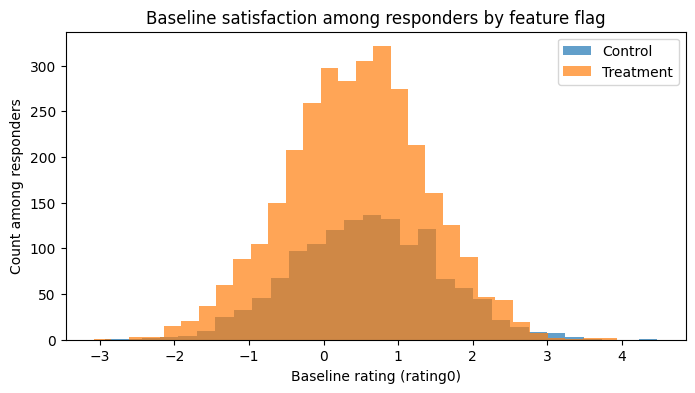

In [16]:
plt.figure(figsize=(8,4))
plt.hist(responders.loc[responders.feature_flag == 0, "rating0"], bins=30, alpha=0.7, label="Control")
plt.hist(responders.loc[responders.feature_flag == 1, "rating0"], bins=30, alpha=0.7, label="Treatment")
plt.xlabel("Baseline rating (rating0)")
plt.ylabel("Count among responders")
plt.title("Baseline satisfaction among responders by feature flag")
plt.legend()
plt.show()

## 7. Final thoughts

- We implemented a version-agnostic d-separation checker using only networkx.

- We used it to demonstrate:

  - **Chains, forks, and colliders** — and how statistical association flows (or gets blocked) in each case.

  - **Backdoor paths and confounding** — where ignoring a common cause (like revenue_prev) can severely bias estimates, and how simple adjustment (stratification) recovers the correct effect.

  - **Selection bias via colliders** — even in a randomized A/B test:
    - True effect: **0.300**
    - Full data estimate: **~0.295 (accurate)**
    - Responders-only estimate: **~0.154 (biased)**
    
    Conditioning on response introduces a collider, distorting the causal estimate.

- The key takeaway:

  > Most analytical errors do not come from the model — they come from conditioning on the wrong variables.

- Causal graphs provide a simple but powerful framework to:
  - Decide **what to control for**
  - Avoid **spurious correlations**
  - Ensure **valid causal interpretation**
